The goal if this notebook is to try and determine what range of values for the ratio of theta and beta between the IDA-FX results and the MSA-SS results would cause a change of engineering significance in the observed mean annual frequency of collapse of our structures.

In [2]:
%load_ext autoreload
%autoreload 2

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hazrisk.risk import theta_ratio_first_order

from phd_project.config import config

cfg = config.load_config()

## 1.0 First-Order Hazard Approximation

### 1.1 Background

We can approximate the hazard as linear in log-space. By doing this and assuming that the fragility can be defined by a log-normal cumulative distribution function then a closed form analytical solution for the ratio between two MAFC levels ($\lambda_1$ and $\lambda_2$) can be found. $$\frac{\lambda_2}{\lambda_1}=R_{\lambda}=(R_{\theta})^{-k_1}\exp{\left[\frac{k_1^2}{2}\left(R_{\beta}^2-1\right)\beta_1^2\right]}$$ where $R_{\theta}$ is the ratio of median capacities, $k$ is the slope of the hazard curve, $\beta_1$ is the dispersion for the reference fragility and $\R_{\beta}$ is the ratio of the dispersions between the two fragilities. This equation can be rearranged to give $R_{\theta}$ as a function of $R_{\lambda}$. $$R_{\theta}=\exp{\left[\frac{k_1}{2}\left(R_{\beta}^2-1\right)\beta_1^2 - \frac{\ln{R_\lambda}}{k_1}\right]}$$

### 1.2 $k_1$-Values for casestudy sites

In [11]:
# load hazard curve fits for AvgSA 0.3s, first order
fo_hc_fits = pd.read_csv(cfg["proc_data"]['AvgSA_03_fo_hc_fits'])
fo_hc_fits["k1"].describe()

count    60.000000
mean      2.291174
std       0.442466
min       1.380932
25%       1.978317
50%       2.309521
75%       2.613243
max       3.010855
Name: k1, dtype: float64

### 1.3 Parameters

In [43]:
R_lambda = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
k1 = [1.5, 2.0, 2.5, 3.0]
beta_1 = [0.15, 0.2, 0.25, 0.4, 0.5]
R_beta = [0.5, 0.8, 1, 1.2, 1.5, 2.0]      # assume the same beta for the two fragilities

R_thetas = theta_ratio_first_order(R_lambda, k1, beta_1, R_beta)

Text(0.5, 1.0, 'beta_1 on R_theta. k1 : 2.5, R_beta : 1.5')

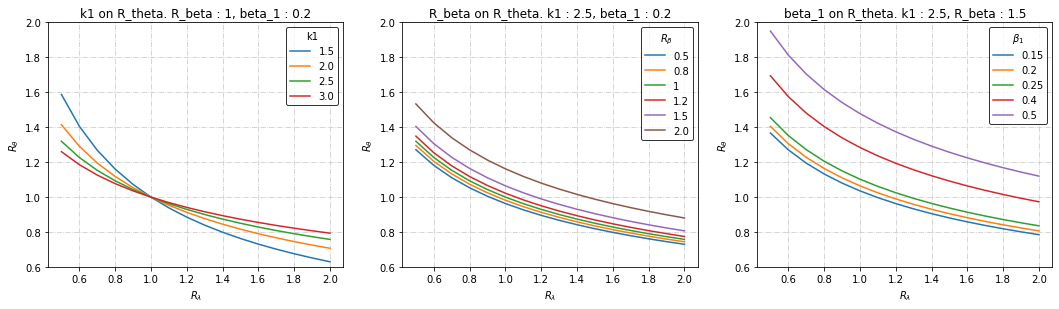

In [63]:
fig, axs = plt.subplots(1, 3,figsize=(18, 4.5), sharex=True)

rb_4_k1 = 2
b_4_k1 = 1

k1_4_rb = 2
b_4_rb = 1

k1_4_b = 2
rb_4_b = 4

for jj, k in enumerate(k1):
    axs[0].plot(R_lambda, R_thetas[:, jj, 1, 2], label=f"{k}")

for kk, rb in enumerate(R_beta):
    axs[1].plot(R_lambda, R_thetas[:, 2, 1, kk], label=f"{rb}")

for ll, b in enumerate(beta_1):
    axs[2].plot(R_lambda, R_thetas[:, 2, ll, 4], label=f"{b}")

for ax, var in zip(axs, ["k1", r"$R_{\beta}$", r"$\beta_1$"]):
    ax.grid(ls="-.", color="0.8")
    ax.set_xlabel(r"$R_{\lambda}$")
    ax.set_ylabel(r"$R_{\theta}$")
    ax.set_ylim(0.6, 2.0)
    leg = ax.legend(title=var)
    frame = leg.get_frame()
    frame.set_edgecolor('k')

axs[0].set_title(r"k1 on R_theta. " + r"R_beta : " + f"{R_beta[rb_4_k1]}" + r", beta_1 : " + f"{beta_1[b_4_k1]}")
axs[1].set_title(r"R_beta on R_theta. " + r"k1 : " + f"{k1[k1_4_rb]}" + r", beta_1 : " + f"{beta_1[b_4_rb]}")
axs[2].set_title(r"beta_1 on R_theta. " + r"k1 : " + f"{k1[k1_4_b]}" + r", R_beta : " + f"{R_beta[rb_4_b]}")